# Child Food Allergy Analysis

This notebook contains the non-regression analysis cells split from `Child_Food_Allergy.ipynb`.


In [1]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML
HTML('''
<style>
div.input {display:none;}
</style>
''')

In [2]:
# read the original data
children = pd.read_csv('child24.csv')


In [3]:
# DEMOGRAPHICS

demographics = ["SEX_C", "RELTIVP_C", "RACEALLP_C"]

# MAIN OUTCOME
main_outcome = ["PHSTAT_C"]

# PSYCHOSOCIAL COVARIATES
psychosocial_covariates = ["ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C"]

# SOCIAL DETERMINANTS OF HEALTH COVARIATES

# Income, Insurance

social_determinants = ["NOTCOV_C", "COVER_C", "FSNAP12M_C", "FWIC12M_C", "FLUNCH12M1_C"]

# Education
education = ["MAXPAREDUP_C"]

# Food Security

# FDSCAT34_C
food_security = ["FDSCAT3_C", "FDSCAT4_C"]

# Housing
housing = ["HOUTENURE_C"]

# Built Environment
built_environment = ["SIDEWALK_C", "PARKS_C", "TRAFFIC_C", "CRIME_C"]

# ELIGIBILITY
eligibility = ["AGEP_C", "CURFOOD_C"]

# Variables
variables = [
    *demographics,
    *main_outcome,
    *psychosocial_covariates,
    *social_determinants,
    *education,
    *food_security,
    *housing,
    *built_environment,
    *eligibility
]


child_data = children[variables]

In [4]:
# Limit the age range

children_with_age_range = child_data[
    child_data["AGEP_C"].between(5, 17)
]

# children_with_age_range

# Analysis

What factors are associated with health status among children with food allergies?  
How does this differ when compared to children without food allergies?

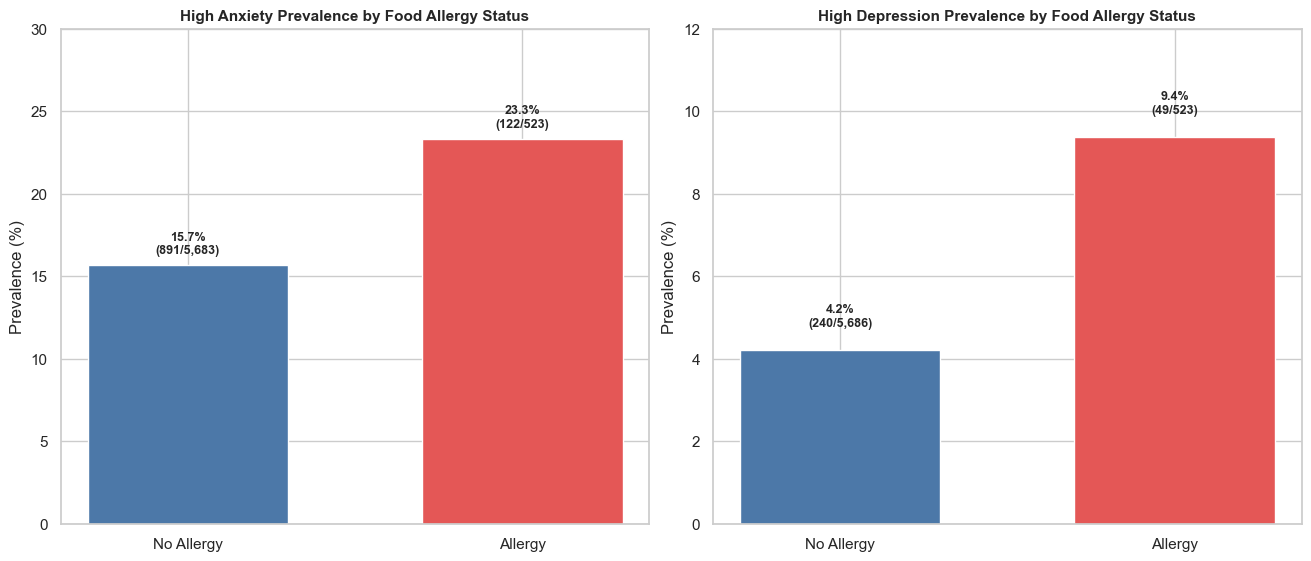

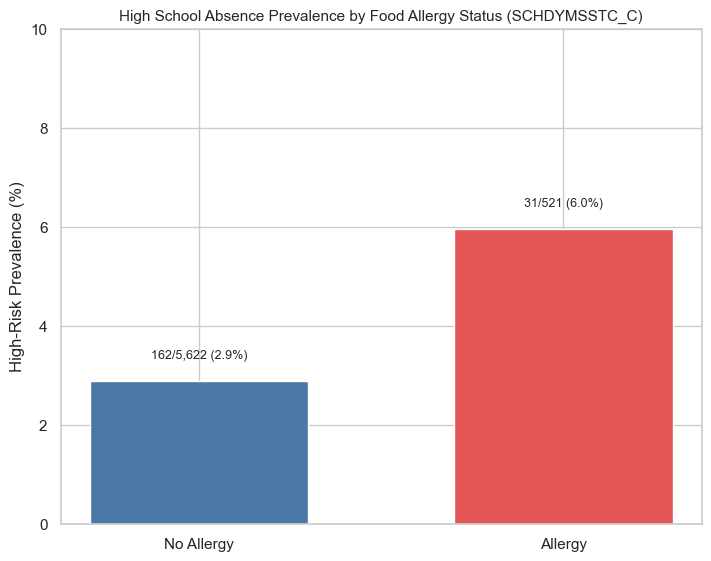


=== high_anxiety ===


high_anxiety,Not High-Risk,High-Risk
food_allergy,,
No Allergy,4792,891
Allergy,401,122


chi2 = 19.9569, p-value = 7.92095e-06, dof = 1

=== high_depression ===


high_depression,Not High-Risk,High-Risk
food_allergy,,
No Allergy,5446,240
Allergy,474,49


chi2 = 27.4546, p-value = 1.60825e-07, dof = 1

=== high_absence ===


high_absence,Not High-Risk,High-Risk
food_allergy,,
No Allergy,5460,162
Allergy,490,31


chi2 = 13.7627, p-value = 0.000207419, dof = 1


In [5]:
from scipy.stats import chi2_contingency

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2]), 1,
    np.where(dep.isin([3, 4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    (sch >= 18) & (sch <= 95), 1,
    np.where((sch >= 0) & (sch <= 17), 0, np.nan)
)

# -----------------------------------
# 2) Plots
# -----------------------------------
sns.set_theme(style="whitegrid")

outcomes = [
    ("high_anxiety", "High Anxiety Prevalence by Food Allergy Status"),
    ("high_depression", "High Depression Prevalence by Food Allergy Status"),
    ("high_absence", "High School Absence Prevalence by Food Allergy Status (SCHDYMSSTC_C)"),
]

colors = ["#4C78A8", "#E45756"]
chi_results = []
plot_data = {}

for outcome, title in outcomes:
    sub = df.dropna(subset=["food_allergy", outcome]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[outcome] = sub[outcome].astype(int)

    ct = pd.crosstab(sub["food_allergy"], sub[outcome]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )

    high_counts = ct[1]
    totals = ct.sum(axis=1)
    high_pct = high_counts / totals * 100

    plot_data[outcome] = {
        "title": title,
        "high_counts": high_counts,
        "totals": totals,
        "high_pct": high_pct,
    }

    chi2, p, dof, exp = chi2_contingency(ct)
    chi_results.append({
        "Outcome": outcome,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "crosstab": ct
    })

# 2a) High anxiety + high depression in one row
panel_outcomes = ["high_anxiety", "high_depression"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

for ax, outcome in zip(axes, panel_outcomes):
    item = plot_data[outcome]
    x_labels = ["No Allergy", "Allergy"]
    y_vals = [item["high_pct"].loc[0], item["high_pct"].loc[1]]
    bars = ax.bar(x_labels, y_vals, color=colors, width=0.6)

    for i, grp in enumerate([0, 1]):
        cnt = int(item["high_counts"].loc[grp])
        tot = int(item["totals"].loc[grp])
        pct = float(item["high_pct"].loc[grp])
        ax.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.5,
            f"{pct:.1f}%\n({cnt:,}/{tot:,})",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="semibold"
        )

    ax.set_title(item["title"], fontsize=11, fontweight="semibold")
    ax.set_ylabel("Prevalence (%)")

    if outcome == "high_anxiety":
        ax.set_ylim(0, 30)
    else:
        ax.set_ylim(0, 12)

plt.show()

# 2b) Keep high absence as a separate plot
item = plot_data["high_absence"]
fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
x_labels = ["No Allergy", "Allergy"]
y_vals = [item["high_pct"].loc[0], item["high_pct"].loc[1]]
bars = ax.bar(x_labels, y_vals, color=colors, width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(item["high_counts"].loc[grp])
    tot = int(item["totals"].loc[grp])
    pct = float(item["high_pct"].loc[grp])
    ax.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.4,
        f"{cnt:,}/{tot:,} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(item["title"], fontsize=11)
ax.set_ylabel("High-Risk Prevalence (%)")
ax.set_ylim(0, 10)
plt.show()

# -----------------------------------
# 3) Crosstabs + chi-square results
# -----------------------------------
for r in chi_results:
    print(f"\n=== {r['Outcome']} ===")
    ct_show = r["crosstab"].rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Not High-Risk", 1: "High-Risk"}
    )
    display(ct_show)
    print(f"chi2 = {r['chi2']:.4f}, p-value = {r['p_value']:.6g}, dof = {r['dof']}")


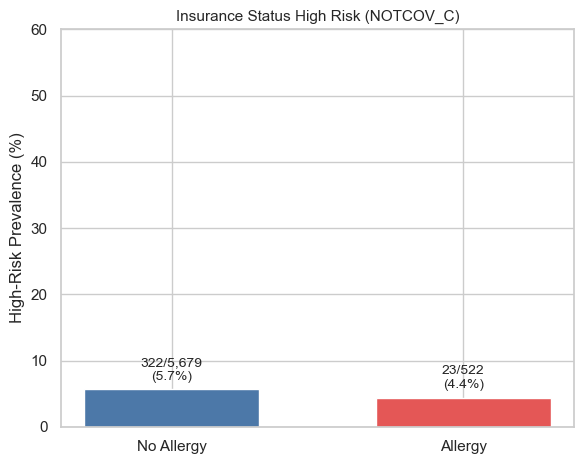

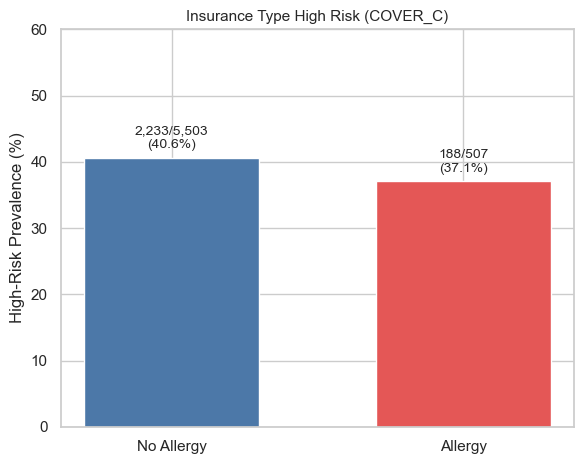

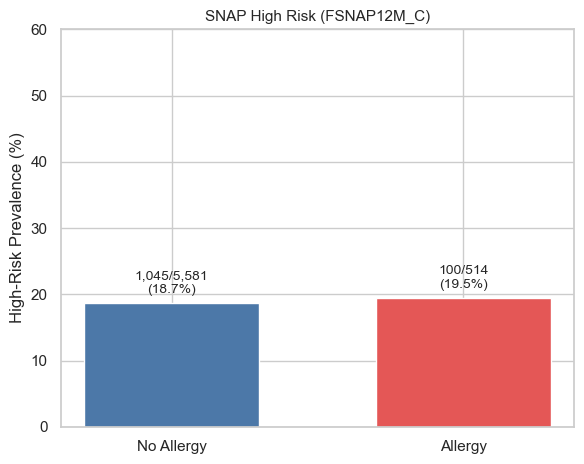

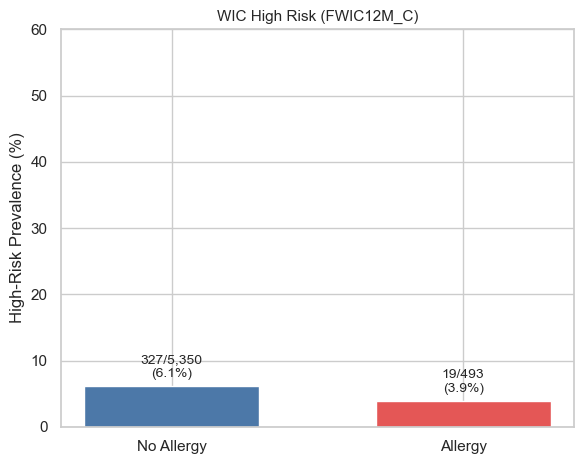

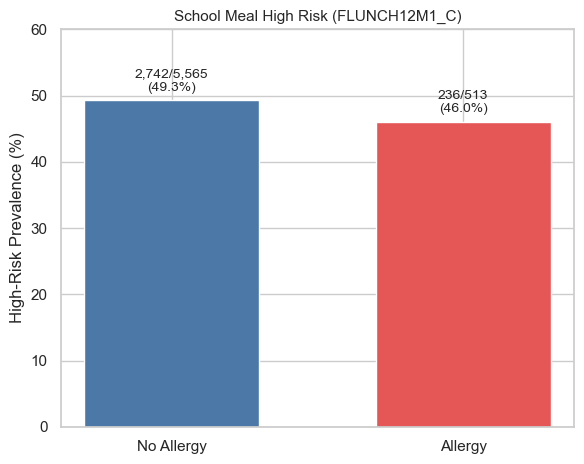

### Insurance Status High Risk (NOTCOV_C)

,Low Risk (0),High Risk (1)
No Allergy,5357,322
Allergy,499,23


,chi_square,p_value,degrees_of_freedom,significant
0,1.2228,0.2688,1,False


### Insurance Type High Risk (COVER_C)

,Low Risk (0),High Risk (1)
No Allergy,3270,2233
Allergy,319,188


...

,Low Risk (0),High Risk (1)
No Allergy,5023,327
Allergy,474,19


,chi_square,p_value,degrees_of_freedom,significant
0,3.7366,0.0532,1,False


### School Meal High Risk (FLUNCH12M1_C)

,Low Risk (0),High Risk (1)
No Allergy,2823,2742
Allergy,277,236


,chi_square,p_value,degrees_of_freedom,significant
0,1.8791,0.1704,1,False


In [6]:
# -----------------------------------
# 1) Base data: age 5-17, keep both allergy groups
# -----------------------------------
df = children_with_age_range.copy()
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------------
# 2) Recode socioeconomic variables to binary risk
# -----------------------------------
def recode_notcov(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1  # uninsured = high risk
    out[s == 2] = 0  # insured = low risk
    return out

def recode_cover(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 0
    out[s.isin([2, 4])] = 1
    return out

def recode_yesno_risk(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1
    out[s == 2] = 0
    return out

df["notcov_risk"] = recode_notcov(df["NOTCOV_C"])
df["cover_risk"] = recode_cover(df["COVER_C"])
df["food_stamp_risk"] = recode_yesno_risk(df["FSNAP12M_C"])
df["wic_risk"] = recode_yesno_risk(df["FWIC12M_C"])
df["meal_risk"] = recode_yesno_risk(df["FLUNCH12M1_C"])

# -----------------------------------
# 3) Plot each variable separately (1 row, 1 chart each)
# -----------------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("notcov_risk", "Insurance Status High Risk (NOTCOV_C)"),
    ("cover_risk", "Insurance Type High Risk (COVER_C)"),
    ("food_stamp_risk", "SNAP High Risk (FSNAP12M_C)"),
    ("wic_risk", "WIC High Risk (FWIC12M_C)"),
    ("meal_risk", "School Meal High Risk (FLUNCH12M1_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pct = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(6, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pct.loc[0], pct.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        p = float(pct.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 1.0,
            f"{cnt:,}/{tot:,}\n({p:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title, fontsize=11)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 60)
    plt.tight_layout()
    plt.show()

from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# -----------------------------------
# 4) Chi-square test for each variable separately
# -----------------------------------
for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    contingency = pd.crosstab(sub["food_allergy"], sub[col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    contingency.index = ["No Allergy", "Allergy"]
    contingency.columns = ["Low Risk (0)", "High Risk (1)"]

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    display(Markdown(f"### {title}"))
    display(contingency)

    result_df = pd.DataFrame({
        "chi_square": [round(chi2, 4)],
        "p_value": [round(p_value, 4)],
        "degrees_of_freedom": [dof],
        "significant": [p_value < 0.05]
    })
    display(result_df)


Crosstab: Count


,cover_group,No Allergy,Allergy
0,Medicaid or other public,1911,165
1,Other coverage,176,15
2,Private,3270,319
3,Uninsured,322,23


Crosstab: Row Percentage


,cover_group,No Allergy (%),Allergy (%)
0,Medicaid or other public,92.05,7.95
1,Other coverage,92.15,7.85
2,Private,91.11,8.89
3,Uninsured,93.33,6.67


Food allergy by COVER_C category


,cover_group,allergy_count,total_n,allergy_percent
0,Medicaid or other public,165,2076,7.95
1,Other coverage,15,191,7.85
2,Private,319,3589,8.89
3,Uninsured,23,345,6.67


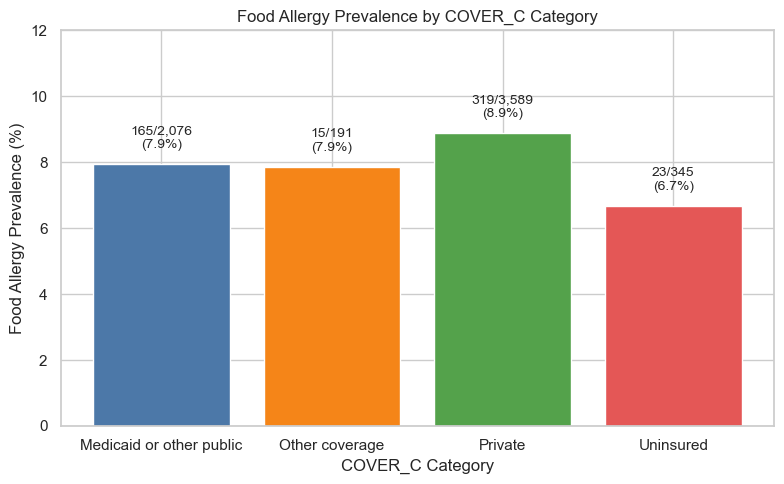

In [7]:
# -----------------------------------
# COVER_C: category별 food allergy count + percentage
# -----------------------------------
df = children_with_age_range.copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

cover = pd.to_numeric(df["COVER_C"], errors="coerce")

# COVER_C 원자료 category 유지
# 필요하면 아래 label_map은 코드북에 맞게 수정
label_map = {
    1: "Private",
    2: "Medicaid or other public",
    3: "Other coverage",
    4: "Uninsured"
}

df["cover_group"] = cover.map(label_map)

analysis_df = df.dropna(subset=["food_allergy", "cover_group"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)

# Count table
ct_count = pd.crosstab(analysis_df["cover_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

# Row percentage
ct_pct = pd.crosstab(
    analysis_df["cover_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

print("Crosstab: Count")
display(ct_count.reset_index(names="cover_group"))

print("Crosstab: Row Percentage")
display(ct_pct.round(2).reset_index(names="cover_group"))

# Allergy count / total / prevalence
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)
allergy_pct = ct_pct["Allergy (%)"]

summary_df = pd.DataFrame({
    "cover_group": ct_count.index,
    "allergy_count": allergy_counts.values,
    "total_n": group_totals.values,
    "allergy_percent": allergy_pct.values
})

print("Food allergy by COVER_C category")
display(summary_df.round(2))

# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(summary_df["cover_group"], summary_df["allergy_percent"],
               color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])

plt.ylim(0, 12)

for i, bar in enumerate(bars):
    cnt = int(summary_df.iloc[i]["allergy_count"])
    tot = int(summary_df.iloc[i]["total_n"])
    pct = float(summary_df.iloc[i]["allergy_percent"])
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by COVER_C Category")
plt.xlabel("COVER_C Category")
plt.ylabel("Food Allergy Prevalence (%)")
plt.tight_layout()
plt.show()


2x2 Table: Count


,No Allergy,Allergy
education_binary,,
0-5,2202,156
6-10,3338,360


2x2 Table: Row Percentage


,No Allergy (%),Allergy (%)
education_binary,,
0-5,93.38,6.62
6-10,90.27,9.73


Chi-square Test Result


,chi_square,p_value,degrees_of_freedom,significant
0,17.5754,0.000028,1,True


Expected Counts


,No Allergy,Allergy
education_binary,,
0-5,2157.09,200.91
6-10,3382.91,315.09


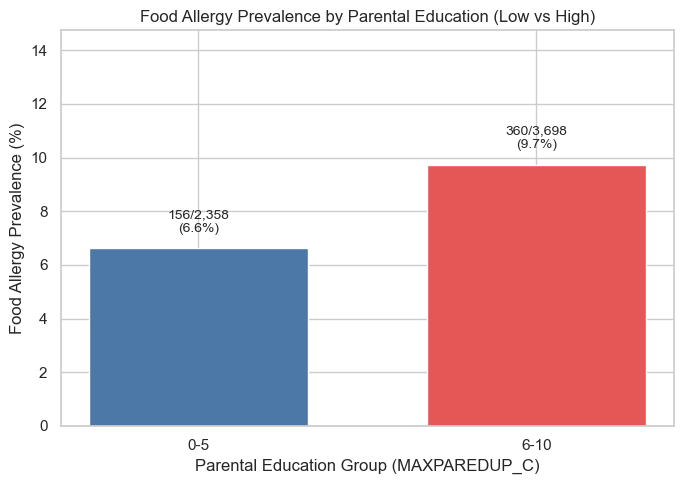

In [8]:
from scipy.stats import chi2_contingency

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# MAXPAREDUP_C recode: 0-5 vs 6-10
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")
df["education_binary"] = np.where(
    maxedu.between(0, 5), "0-5",
    np.where(maxedu.between(6, 10), "6-10", pd.NA)
)

# Remove missing values
analysis_df = df.dropna(subset=["education_binary", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["education_binary"] = pd.Categorical(
    analysis_df["education_binary"],
    categories=["0-5", "6-10"],
    ordered=True
)

# -----------------------------------
# 2) 2x2 contingency table
# -----------------------------------
ct_count = pd.crosstab(analysis_df["education_binary"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["0-5", "6-10"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["education_binary"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["0-5", "6-10"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

print("2x2 Table: Count")
display(ct_count)

print("2x2 Table: Row Percentage")
display(ct_pct.round(2))

# -----------------------------------
# 3) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 10)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square Test Result")
display(chi_result)

expected_df = pd.DataFrame(
    expected,
    index=ct_count.index,
    columns=ct_count.columns
)

print("Expected Counts")
display(expected_df.round(2))

# -----------------------------------
# 4) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(prev_pct.index, prev_pct.values, color=["#4C78A8", "#E45756"], width=0.65)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Parental Education (Low vs High)")
plt.xlabel("Parental Education Group (MAXPAREDUP_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, max(prev_pct.values) + 5)
plt.tight_layout()
plt.show()


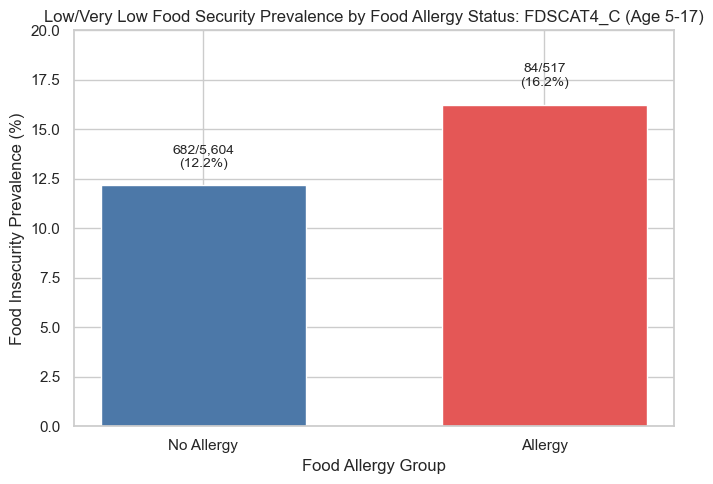

Crosstab (count):


food_insecure,High/Marginal,Low/Very Low
food_allergy,,
No Allergy,4922,682
Allergy,433,84


Chi-square test result


,chi_square,p_value,degrees_of_freedom,significant
0,6.8211,0.009009,1,True


In [9]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age range: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C: 1=Allergy, 2=No Allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) FDSCAT4_C -> food_insecure
# 3,4 -> 1 (Low/Very Low), 1,2 -> 0 (High/Marginal), others(8,etc.) -> NaN
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "food_insecure"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["food_insecure"] = analysis_df["food_insecure"].astype(int)

# -----------------------------------
# 2) Crosstab + prevalence
# -----------------------------------
ct = pd.crosstab(analysis_df["food_allergy"], analysis_df["food_insecure"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy
# col 1: Low/Very Low food security count

insecure_counts = ct[1]
totals = ct.sum(axis=1)
insecure_pct = (insecure_counts / totals * 100)



# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

x_labels = ["No Allergy", "Allergy"]
y_vals = [insecure_pct.loc[0], insecure_pct.loc[1]]
bars = plt.bar(x_labels, y_vals, color=["#4C78A8", "#E45756"], width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(insecure_counts.loc[grp])
    tot = int(totals.loc[grp])
    pct = float(insecure_pct.loc[grp])
    plt.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.8,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Low/Very Low Food Security Prevalence by Food Allergy Status: FDSCAT4_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Food Insecurity Prevalence (%)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()


# Display crosstab
ct_show = ct.rename(index={0: "No Allergy", 1: "Allergy"},
                    columns={0: "High/Marginal", 1: "Low/Very Low"})
print("Crosstab (count):")
display(ct_show)

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 6)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square test result")
display(chi_result)



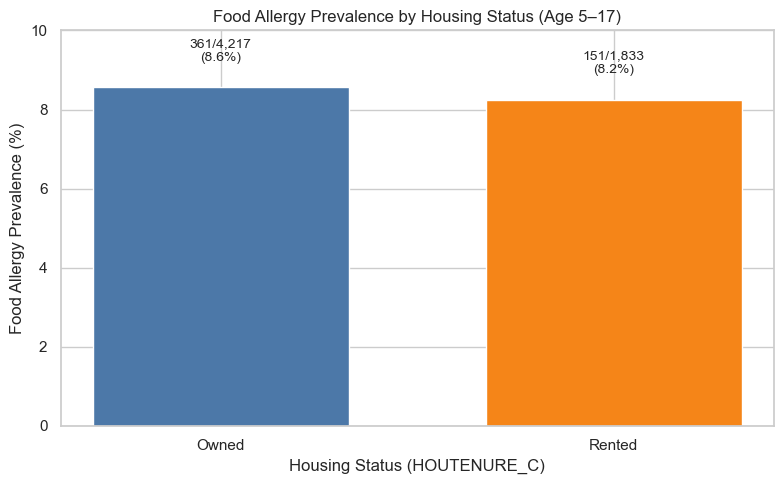

Chi-square test result


,chi_square,p_value,degrees_of_freedom,significant
0,0.1326,0.715706,1,False


2x2 Table: Count


,No Allergy,Allergy
housing_group,,
Owned,3856,361
Rented,1682,151


2x2 Table: Row Percentage


,No Allergy (%),Allergy (%)
housing_group,,
Owned,91.44,8.56
Rented,91.76,8.24


In [10]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) HOUTENURE_C recode
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
housing_map = {1: "Owned", 2: "Rented"}
df["housing_group"] = house.map(housing_map)  # 7,8,9 and others -> NaN


# Remove missing values
analysis_df = df.dropna(subset=["housing_group", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["housing_group"] = pd.Categorical(
    analysis_df["housing_group"],
    categories=["Owned", "Rented"],
    ordered=True
)

# -----------------------------------
# 2) Crosstab (count + row %)
# -----------------------------------
ct_count = pd.crosstab(analysis_df["housing_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["Owned", "Rented"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["housing_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["Owned", "Rented"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

# Display tables with one-line header style
# print("Crosstab: Count")
# display(ct_count.rename_axis(None).reset_index(names="housing_group"))

# print("Crosstab: Row Percentage")
# display(ct_pct.round(2).rename_axis(None).reset_index(names="housing_group"))

# -----------------------------------
# 3) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(
    prev_pct.index,
    prev_pct.values,
    color=["#4C78A8", "#F58518"],
    width=0.65
)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Housing Status (Age 5–17)")
plt.xlabel("Housing Status (HOUTENURE_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

from scipy.stats import chi2_contingency

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 6)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square test result")
display(chi_result)

expected_df = pd.DataFrame(
    expected,
    index=ct_count.index,
    columns=ct_count.columns
)

print("2x2 Table: Count")
display(ct_count)

print("2x2 Table: Row Percentage")
display(ct_pct.round(2))


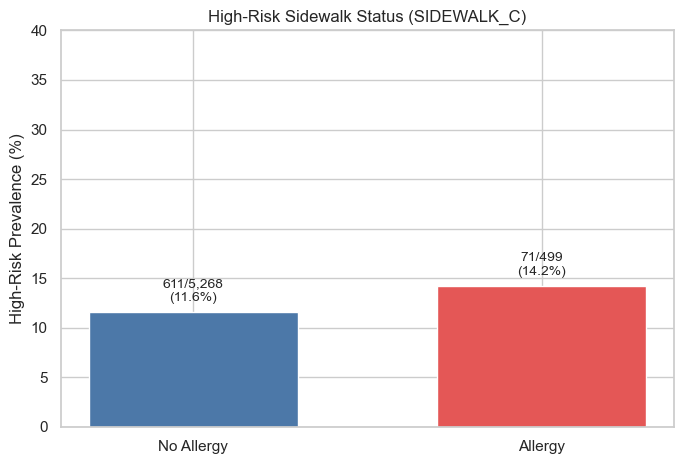

**High-Risk Sidewalk Status (SIDEWALK_C): 2x2 Table**

sidewalk_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4657,611
Allergy,428,71


**High-Risk Sidewalk Status (SIDEWALK_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.777,0.095629,1,False


**High-Risk Sidewalk Status (SIDEWALK_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4645.01,622.99
Allergy,439.99,59.01


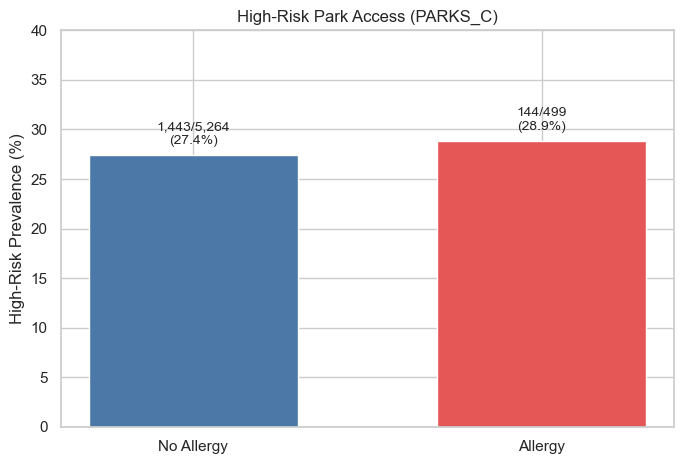

**High-Risk Park Access (PARKS_C): 2x2 Table**

parks_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3821,1443
Allergy,355,144


**High-Risk Park Access (PARKS_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,0.4073,0.523325,1,False


**High-Risk Park Access (PARKS_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3814.41,1449.59
Allergy,361.59,137.41


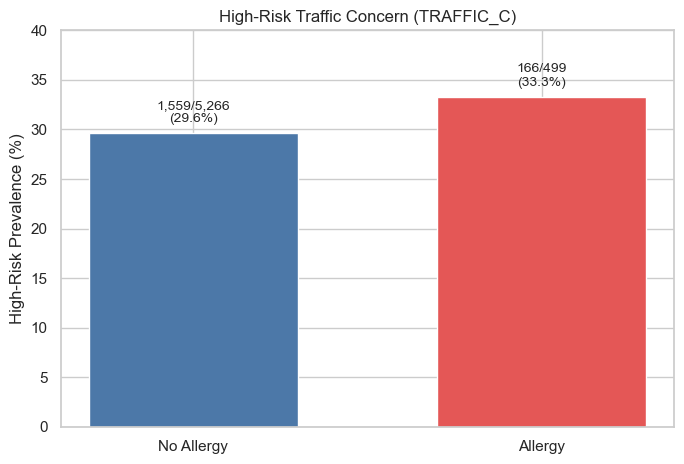

**High-Risk Traffic Concern (TRAFFIC_C): 2x2 Table**

traffic_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3707,1559
Allergy,333,166


**High-Risk Traffic Concern (TRAFFIC_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.7423,0.097725,1,False


**High-Risk Traffic Concern (TRAFFIC_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3690.31,1575.69
Allergy,349.69,149.31


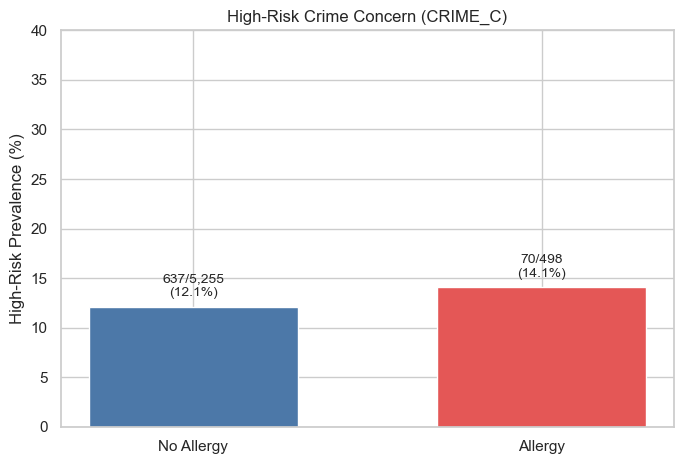

**High-Risk Crime Concern (CRIME_C): 2x2 Table**

crime_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4618,637
Allergy,428,70


**High-Risk Crime Concern (CRIME_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,1.4048,0.235915,1,False


**High-Risk Crime Concern (CRIME_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4609.2,645.8
Allergy,436.8,61.2


In [11]:
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# -----------------------------
# 1) Filter: age 5-17 + keep both allergy groups
# -----------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------
# 2) Recode built environment to high-risk indicators
# -----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

sidewalk = to_num(df["SIDEWALK_C"])
parks = to_num(df["PARKS_C"])
traffic = to_num(df["TRAFFIC_C"])
crime = to_num(df["CRIME_C"])

# High-risk:
# Sidewalk/Parks: No(2)=1 high-risk, Yes(1)=0
# Traffic/Crime: Yes(1)=1 high-risk, No(2)=0
df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# -----------------------------
# 3) Plot each variable separately
# -----------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("sidewalk_high_risk", "High-Risk Sidewalk Status (SIDEWALK_C)"),
    ("parks_high_risk", "High-Risk Park Access (PARKS_C)"),
    ("traffic_high_risk", "High-Risk Traffic Concern (TRAFFIC_C)"),
    ("crime_high_risk", "High-Risk Crime Concern (CRIME_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pcts = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(7, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pcts.loc[0], pcts.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(pcts.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.8,
            f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 40)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 4) 2x2 table + chi-square result for each variable
    # -----------------------------
    ct = pd.crosstab(sub["food_allergy"], sub[col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    ct_show = ct.rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Low Risk (0)", 1: "High Risk (1)"}
    )

    chi2, p_value, dof, expected = chi2_contingency(ct)

    chi_result = pd.DataFrame({
        "chi_square": [round(chi2, 4)],
        "p_value": [round(p_value, 6)],
        "degrees_of_freedom": [dof],
        "significant": [p_value < 0.05]
    })

    display(Markdown(f"**{title}: 2x2 Table**"))
    display(ct_show)

    display(Markdown(f"**{title}: Chi-square Test Result**"))
    display(chi_result)

    expected_df = pd.DataFrame(
        expected,
        index=["No Allergy", "Allergy"],
        columns=["Low Risk (0)", "High Risk (1)"]
    )

    display(Markdown(f"**{title}: Expected Counts**"))
    display(expected_df.round(2))


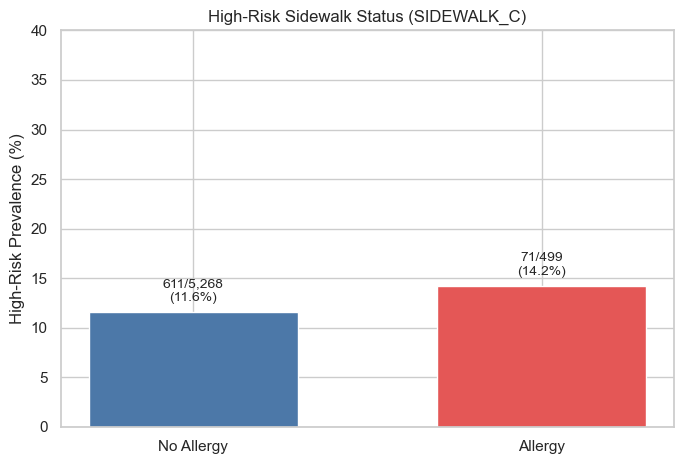

**High-Risk Sidewalk Status (SIDEWALK_C): 2x2 Table**

sidewalk_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4657,611
Allergy,428,71


**High-Risk Sidewalk Status (SIDEWALK_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.777,0.095629,1,False


**High-Risk Sidewalk Status (SIDEWALK_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4645.01,622.99
Allergy,439.99,59.01


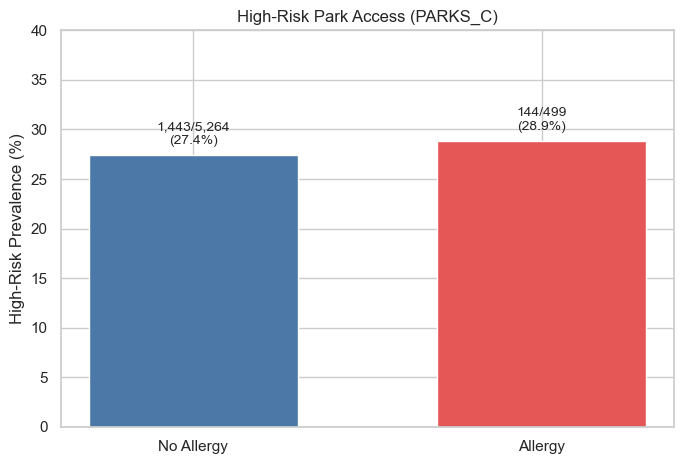

**High-Risk Park Access (PARKS_C): 2x2 Table**

parks_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3821,1443
Allergy,355,144


**High-Risk Park Access (PARKS_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,0.4073,0.523325,1,False


**High-Risk Park Access (PARKS_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3814.41,1449.59
Allergy,361.59,137.41


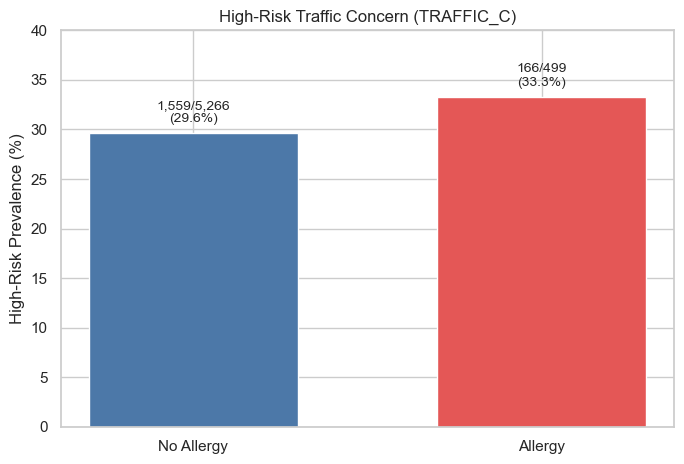

**High-Risk Traffic Concern (TRAFFIC_C): 2x2 Table**

traffic_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3707,1559
Allergy,333,166


**High-Risk Traffic Concern (TRAFFIC_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.7423,0.097725,1,False


**High-Risk Traffic Concern (TRAFFIC_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3690.31,1575.69
Allergy,349.69,149.31


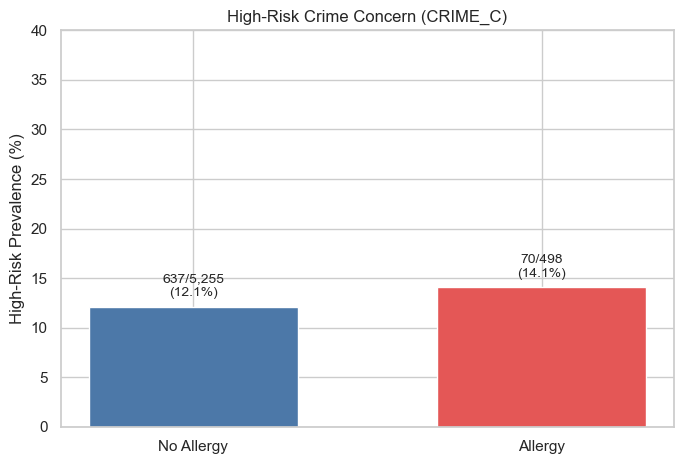

**High-Risk Crime Concern (CRIME_C): 2x2 Table**

crime_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4618,637
Allergy,428,70


**High-Risk Crime Concern (CRIME_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,1.4048,0.235915,1,False


**High-Risk Crime Concern (CRIME_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4609.2,645.8
Allergy,436.8,61.2


In [12]:
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# -----------------------------
# 1) Filter: age 5-17 + keep both allergy groups
# -----------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------
# 2) Recode built environment to high-risk indicators
# -----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

sidewalk = to_num(df["SIDEWALK_C"])
parks = to_num(df["PARKS_C"])
traffic = to_num(df["TRAFFIC_C"])
crime = to_num(df["CRIME_C"])

# High-risk:
# Sidewalk/Parks: No(2)=1 high-risk, Yes(1)=0
# Traffic/Crime: Yes(1)=1 high-risk, No(2)=0
df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# -----------------------------
# 3) Plot each variable separately
# -----------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("sidewalk_high_risk", "High-Risk Sidewalk Status (SIDEWALK_C)"),
    ("parks_high_risk", "High-Risk Park Access (PARKS_C)"),
    ("traffic_high_risk", "High-Risk Traffic Concern (TRAFFIC_C)"),
    ("crime_high_risk", "High-Risk Crime Concern (CRIME_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pcts = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(7, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pcts.loc[0], pcts.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(pcts.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.8,
            f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 40)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 4) 2x2 table + chi-square result for each variable
    # -----------------------------
    ct = pd.crosstab(sub["food_allergy"], sub[col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    ct_show = ct.rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Low Risk (0)", 1: "High Risk (1)"}
    )

    chi2, p_value, dof, expected = chi2_contingency(ct)

    chi_result = pd.DataFrame({
        "chi_square": [round(chi2, 4)],
        "p_value": [round(p_value, 6)],
        "degrees_of_freedom": [dof],
        "significant": [p_value < 0.05]
    })

    display(Markdown(f"**{title}: 2x2 Table**"))
    display(ct_show)

    display(Markdown(f"**{title}: Chi-square Test Result**"))
    display(chi_result)

    expected_df = pd.DataFrame(
        expected,
        index=["No Allergy", "Allergy"],
        columns=["Low Risk (0)", "High Risk (1)"]
    )

    display(Markdown(f"**{title}: Expected Counts**"))
    display(expected_df.round(2))


Poor health among children with food allergy only:
3/525 (0.57%)


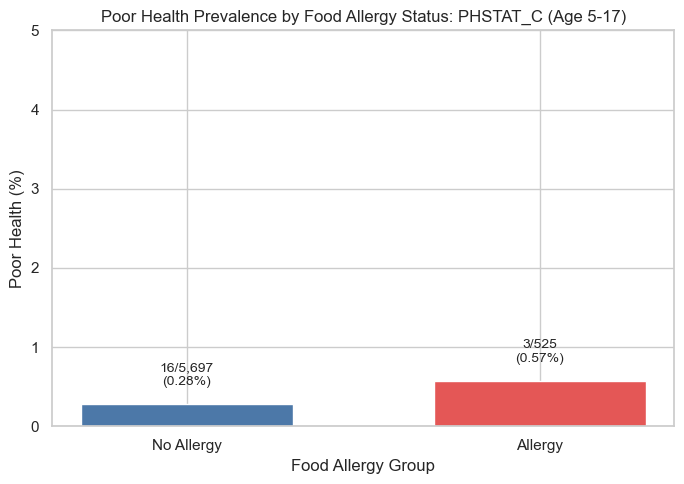


Crosstab (count):


poor_health,Not Poor,Poor
food_allergy,,
No Allergy,5681,16
Allergy,522,3


Chi-square test result:


,chi_square,p_value,degrees_of_freedom,significant
0,0.5496,0.458486,1,False


Expected counts:


,Not Poor,Poor
No Allergy,5679.6,17.4
Allergy,523.4,1.6


In [13]:
# CURFOOD_C vs. PHSTAT_C

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C recode: 1=Allergy, 2=No allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# PHSTAT_C recode: 5=Poor health(1), 1/2/3/4=Not poor(0), others=NaN
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.eq(5), 1,
    np.where(ph.isin([1, 2, 3, 4]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "poor_health"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["poor_health"] = analysis_df["poor_health"].astype(int)

# -----------------------------------
# 2) Analysis
# -----------------------------------
# (1) Poor health prevalence among allergy group only
allergy_only = analysis_df[analysis_df["food_allergy"] == 1]
allergy_poor_rate = allergy_only["poor_health"].mean() * 100
allergy_poor_count = int(allergy_only["poor_health"].sum())
allergy_total = len(allergy_only)

print("Poor health among children with food allergy only:")
print(f"{allergy_poor_count:,}/{allergy_total:,} ({allergy_poor_rate:.2f}%)")

# (2) Compare prevalence by allergy status
ct_count = pd.crosstab(analysis_df["food_allergy"], analysis_df["poor_health"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy; column 1 = poor health count
poor_pct = (ct_count[1] / ct_count.sum(axis=1) * 100)
poor_pct.index = ["No Allergy", "Allergy"]

poor_counts = ct_count[1].copy()
poor_counts.index = ["No Allergy", "Allergy"]
group_totals = ct_count.sum(axis=1).copy()
group_totals.index = ["No Allergy", "Allergy"]

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(poor_pct.index, poor_pct.values, color=["#4C78A8", "#E45756"], width=0.6)

for i, bar in enumerate(bars):
    grp = poor_pct.index[i]
    cnt = int(poor_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = poor_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{cnt:,}/{tot:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Poor Health Prevalence by Food Allergy Status: PHSTAT_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Poor Health (%)")
plt.ylim(0, max(5, poor_pct.max() * 1.35))
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

ct_show = ct_count.rename(
    index={0: "No Allergy", 1: "Allergy"},
    columns={0: "Not Poor", 1: "Poor"}
)

print("\nCrosstab (count):")
display(ct_show)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 20)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square test result:")
display(chi_result)

expected_df = pd.DataFrame(
    expected,
    index=["No Allergy", "Allergy"],
    columns=["Not Poor", "Poor"]
)

print("Expected counts:")
display(expected_df.round(2))


School absence days (SCHDYMSSTC_C) by food allergy status, ages 5-17


,Group,N,Mean,SD
0,No Allergy,5622,3.75,5.57
1,Allergy,521,5.36,7.20


,Comparison,t statistic,df,p value,Mean difference,95% CI lower,95% CI upper
0,Allergy vs No Allergy,4.962,579.07,9.194964e-07,1.61,0.97,2.25


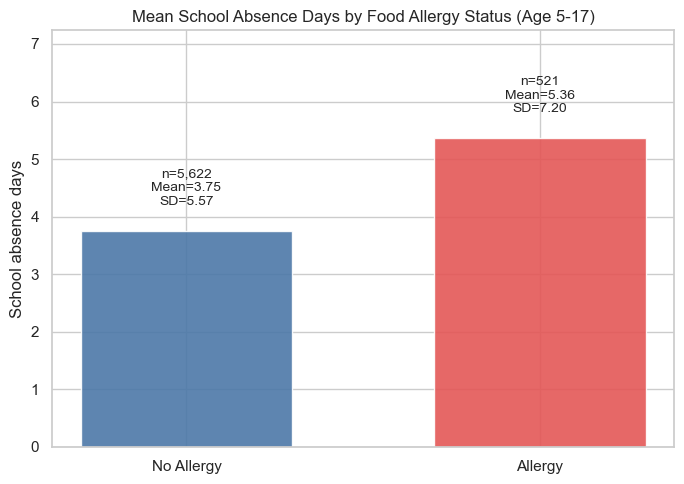

School-aged children with food allergies had significantly more missed school days (mean=5.36) than children without food allergies (mean=3.75; mean difference=1.61, 95% CI 0.97 to 2.25, p=0.000001).


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

# =========================================================
# School absence days (continuous) by food allergy status
# Age restricted to 5-17 years
# =========================================================

df = child_data.copy()

# 1) Restrict to ages 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# 2) Food allergy status: 1 = Allergy, 0 = No allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# 3) School absence days as a continuous variable
absence = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["school_absence_days"] = np.where(absence.between(0, 94), absence, np.nan)

# 4) Complete cases for analysis
analysis_df = df[["food_allergy", "school_absence_days"]].dropna().copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)

# 5) Split into groups
no_allergy = analysis_df.loc[analysis_df["food_allergy"] == 0, "school_absence_days"]
allergy = analysis_df.loc[analysis_df["food_allergy"] == 1, "school_absence_days"]

# 6) Summary table: N, mean, SD
summary_table = pd.DataFrame({
    "Group": ["No Allergy", "Allergy"],
    "N": [len(no_allergy), len(allergy)],
    "Mean": [no_allergy.mean(), allergy.mean()],
    "SD": [no_allergy.std(ddof=1), allergy.std(ddof=1)]
})
summary_table[["Mean", "SD"]] = summary_table[["Mean", "SD"]].round(2)

# 7) Welch t-test
t_stat, p_value = stats.ttest_ind(allergy, no_allergy, equal_var=False)

# Welch-Satterthwaite degrees of freedom
n1, n0 = len(allergy), len(no_allergy)
m1, m0 = allergy.mean(), no_allergy.mean()
s1, s0 = allergy.var(ddof=1), no_allergy.var(ddof=1)

mean_diff = m1 - m0
se_diff = np.sqrt(s1 / n1 + s0 / n0)

welch_df = (s1 / n1 + s0 / n0) ** 2 / (
    ((s1 / n1) ** 2) / (n1 - 1) + ((s0 / n0) ** 2) / (n0 - 1)
)

# 95% CI for mean difference
t_crit = stats.t.ppf(0.975, welch_df)
ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

ttest_table = pd.DataFrame({
    "Comparison": ["Allergy vs No Allergy"],
    "t statistic": [round(t_stat, 3)],
    "df": [round(welch_df, 2)],
    "p value": [p_value],
    "Mean difference": [round(mean_diff, 2)],
    "95% CI lower": [round(ci_lower, 2)],
    "95% CI upper": [round(ci_upper, 2)]
})

print("School absence days (SCHDYMSSTC_C) by food allergy status, ages 5-17")
display(summary_table)
display(ttest_table)

# 8) Visualization
plot_df = summary_table.copy()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(
    plot_df["Group"],
    plot_df["Mean"],
    color=["#4C78A8", "#E45756"],
    width=0.6,
    alpha=0.9
)

for i, row in plot_df.iterrows():
    plt.text(
        i,
        row["Mean"] + 0.4,
        f"n={int(row['N']):,}\nMean={row['Mean']:.2f}\nSD={row['SD']:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Mean School Absence Days by Food Allergy Status (Age 5-17)")
plt.ylabel("School absence days")
plt.xlabel("")
plt.ylim(0, max(plot_df["Mean"].max() * 1.35, 5))
plt.tight_layout()
plt.show()

# 9) Result sentence
print(
    f"School-aged children with food allergies had significantly more missed school days "
    f"(mean={m1:.2f}) than children without food allergies (mean={m0:.2f}; "
    f"mean difference={mean_diff:.2f}, 95% CI {ci_lower:.2f} to {ci_upper:.2f}, "
    f"p={p_value:.6f})."
)
